# Versao 11 - Classificacao Multiclasse Com LSTM Multitarefa

Este notebook treina exatamente a mesma arquitetura central da `versao10`. A diferenca experimental esta no que chega a ela depois do novo pre-processamento da `versao11`.

## Status Da Execucao Registrada

Os resultados antigos da `versao11` nao devem mais ser usados como referencia, porque foram produzidos antes da correcao conceitual entre `class` e `state`.

A partir desta revisao, este notebook passa a medir a mesma arquitetura multitarefa da `versao10`, mas com o novo foco de treino da `versao11`:

- remover features totalmente vazias;
- manter o problema multiclasse completo `0..9`;
- no treino das classes globais `1..9`, tentar remover observacoes com `class = 0` e manter observacoes com erro ou transiente.

Reexecute este notebook depois do pre-processamento atualizado para registrar metricas compatíveis com a configuracao corrigida.


## O que fica igual em relacao a versao 10

- a rede principal continua sendo multitarefa;
- a entrada continua combinando `X_seq`, `X_tab`, `X_missing`, `X_frozen` e `source_id`;
- as cabecas auxiliares continuam prevendo `class` e `state` por observacao;
- os hiperparametros do treino permanecem os mesmos da `versao10`;
- o que muda e apenas o criterio de foco do treino dentro das series de falha.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao11" else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from versao11.pipeline_v11 import (
    load_bundle,
    load_multitask_temporal_model,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_multitask_model_classes,
    train_multitask_temporal_model,
    evaluate_predictions,
    export_evaluation_artifacts,
)

RUN_NAME = "classificacao_v11_foco_por_class_observacional"
RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v11" / RUN_NAME
LSTM_DIR = RUN_DIR / "lstm"
bundle = load_bundle(RUN_DIR / "bundle_v11.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
validation_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")


In [2]:
training_summary = train_multitask_temporal_model(
    X_train_seq=train_arrays["X_seq"],
    X_train_tab=train_arrays["X_tab"],
    X_train_missing=train_arrays["X_missing"],
    X_train_frozen=train_arrays["X_frozen"],
    y_train=train_arrays["y"],
    y_train_step_class=train_arrays["y_step_class"],
    y_train_step_state=train_arrays["y_step_state"],
    train_source_id=train_arrays["source_id"],
    X_val_seq=validation_arrays["X_seq"],
    X_val_tab=validation_arrays["X_tab"],
    X_val_missing=validation_arrays["X_missing"],
    X_val_frozen=validation_arrays["X_frozen"],
    y_val=validation_arrays["y"],
    y_val_step_class=validation_arrays["y_step_class"],
    y_val_step_state=validation_arrays["y_step_state"],
    val_source_id=validation_arrays["source_id"],
    output_dir=LSTM_DIR,
    class_labels=bundle.class_labels,
    observation_class_codes=bundle.observation_class_codes,
    observation_state_codes=bundle.observation_state_codes,
    source_vocab_size=len(bundle.source_mapping),
    hidden_size=160,
    num_layers=2,
    source_embedding_dim=12,
    tabular_hidden_size=160,
    dropout=0.25,
    learning_rate=5e-4,
    weight_decay=1e-4,
    batch_size=64,
    epochs=55,
    patience=10,
    lambda_step_class=0.35,
    lambda_step_state=0.15,
    random_state=42,
)

training_summary

MultiTaskTrainingSummary(model_name='source_aware_multitask_temporal_model', checkpoint_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_foco_por_class_observacional/lstm/multitask_temporal_best.pt', config_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_foco_por_class_observacional/lstm/multitask_temporal_config.json', history_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_foco_por_class_observacional/lstm/multitask_temporal_history.csv', best_epoch=8, best_val_macro_f1=0.9207894278590274, best_val_accuracy=0.9191616766467066, best_val_balanced_accuracy=0.9282759793891853)

In [3]:
best_model = load_multitask_temporal_model(training_summary.config_path)

validation_pred = predict_multitask_model_classes(
    best_model,
    validation_arrays["X_seq"],
    validation_arrays["X_tab"],
    validation_arrays["X_missing"],
    validation_arrays["X_frozen"],
    validation_arrays["source_id"],
)
test_pred = predict_multitask_model_classes(
    best_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
    test_arrays["X_missing"],
    test_arrays["X_frozen"],
    test_arrays["source_id"],
)

validation_eval = evaluate_predictions(
    validation_arrays["y"],
    validation_pred,
    class_labels=bundle.class_labels,
)
test_eval = evaluate_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(validation_eval, LSTM_DIR, "multitask_validation")
export_evaluation_artifacts(test_eval, LSTM_DIR, "multitask_test")

pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": validation_eval["accuracy"],
            "macro_f1": validation_eval["macro_f1"],
            "balanced_accuracy": validation_eval["balanced_accuracy"],
        },
        {
            "split": "test",
            "accuracy": test_eval["accuracy"],
            "macro_f1": test_eval["macro_f1"],
            "balanced_accuracy": test_eval["balanced_accuracy"],
        },
    ]
)

,split,accuracy,macro_f1,balanced_accuracy
0,validation,0.919162,0.920789,0.928276
1,test,0.919403,0.911840,0.923831


,epoch,learning_rate,train_loss,train_instance_loss,train_step_class_loss,train_step_state_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
13,14,0.00050,0.200072,0.071452,0.269252,0.229212,0.921745,0.923570,0.953313,0.898204,0.847994,0.864822
14,15,0.00025,0.156773,0.058771,0.217061,0.146872,0.955741,0.961737,0.972391,0.940120,0.891020,0.888456
15,16,0.00025,0.119179,0.042620,0.171122,0.111108,0.937139,0.939566,0.964527,0.883234,0.838603,0.858934
16,17,0.00025,0.110033,0.036557,0.149612,0.140745,0.946119,0.949107,0.968146,0.913174,0.867816,0.877189
17,18,0.00025,0.101244,0.032207,0.158110,0.091319,0.968570,0.969820,0.977136,0.946108,0.893892,0.890703


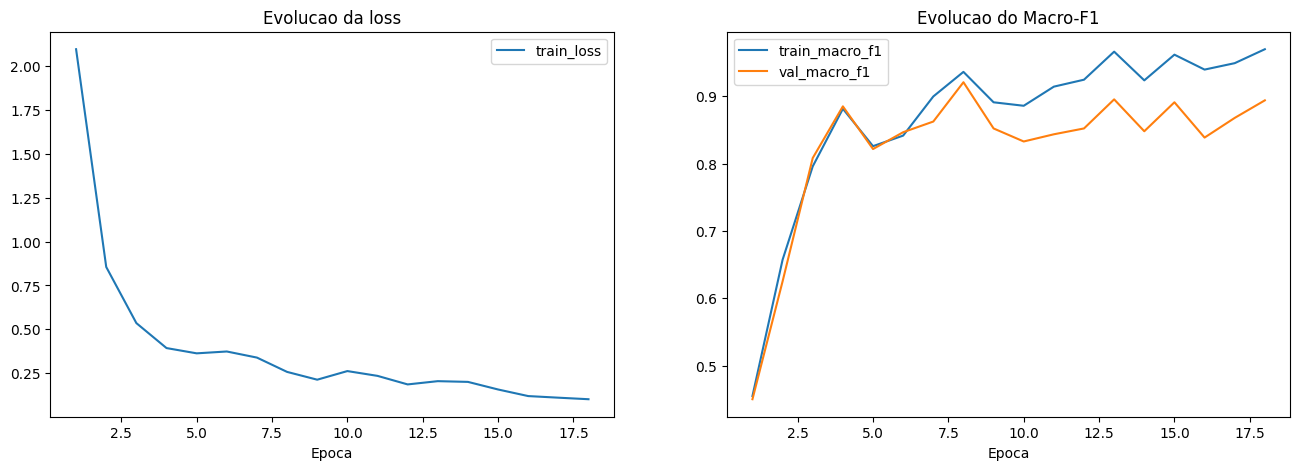

In [4]:
history = pd.read_csv(training_summary.history_path)
display(history.tail())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history["epoch"], history["train_loss"], label="train_loss")
axes[0].set_title("Evolucao da loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_macro_f1"], label="train_macro_f1")
axes[1].plot(history["epoch"], history["val_macro_f1"], label="val_macro_f1")
axes[1].set_title("Evolucao do Macro-F1")
axes[1].set_xlabel("Epoca")
axes[1].legend()
plt.show()

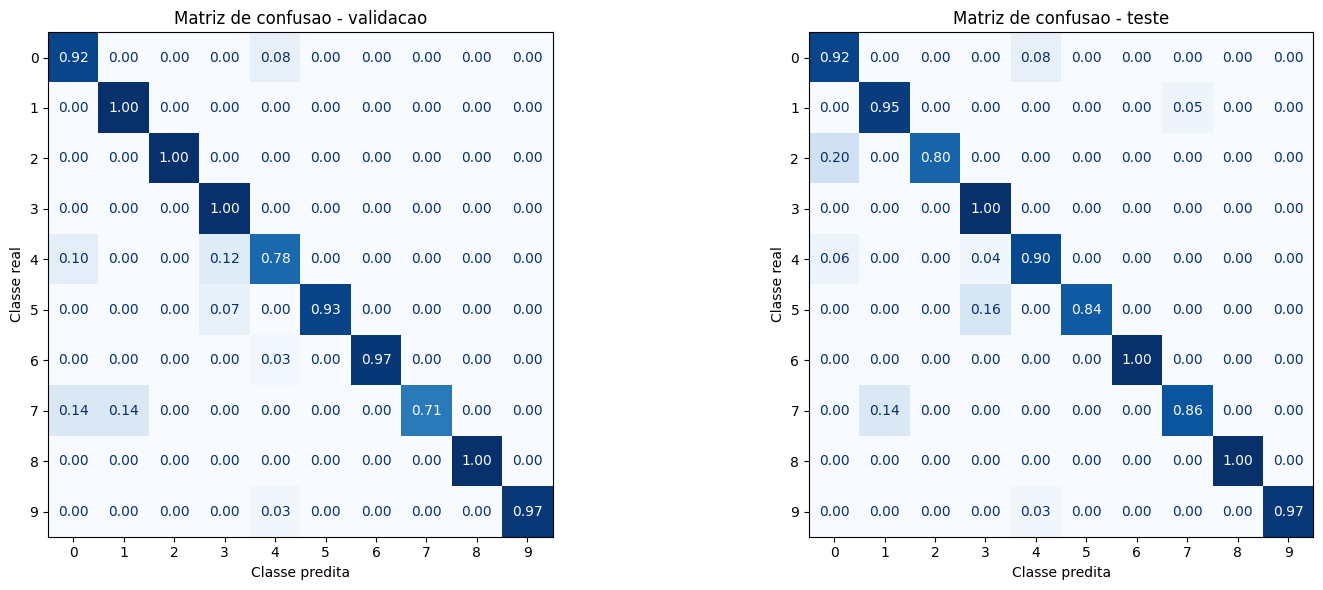

,label,precision,recall,f1-score,support
0,0,0.953488,0.921348,0.937143,89.000000
1,1,0.950000,0.950000,0.950000,20.000000
2,2,1.000000,0.800000,0.888889,5.000000
3,3,0.551724,1.000000,0.711111,16.000000
4,4,0.854545,0.903846,0.878505,52.000000
5,5,1.000000,0.838235,0.912000,68.000000
6,6,1.000000,1.000000,1.000000,33.000000
7,7,0.857143,0.857143,0.857143,7.000000
8,8,1.000000,1.000000,1.000000,14.000000
9,9,1.000000,0.967742,0.983607,31.000000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    validation_arrays["y"],
    validation_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - validacao",
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - teste",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

display(test_eval["classification_report_df"])